# TMDb Integration - Financial Data Analysis

This notebook demonstrates how to integrate TMDb financial data (budget, revenue) with IMDb ratings data.

## What's included:
- Budget and box office revenue
- ROI (Return on Investment) calculations
- Production companies and countries
- TMDb popularity and ratings

## Steps:
1. Set up TMDb API key
2. Load and explore the integrated data
3. Analyze financial features
4. Build enhanced prediction models

## 1. Setup and API Key Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


### Check TMDb API Key

**To get a TMDb API key:**
1. Create an account at https://www.themoviedb.org/signup
2. Go to https://www.themoviedb.org/settings/api
3. Request an API key (free for non-commercial use)
4. Create a `.env` file in the project root with: `TMDB_API_KEY=your_key_here`

In [2]:
# Check if API key is configured
api_key = os.getenv('TMDB_API_KEY')

if api_key:
    print("✅ TMDb API key found")
    print(f"   Key: {api_key[:10]}...{api_key[-4:]}")
else:
    print("❌ TMDb API key not found!")
    print("   Please add TMDB_API_KEY to your .env file")

✅ TMDb API key found
   Key: 03a670e4e7...3958


## 2. Run TMDb Integration (if not already done)

This will fetch financial data from TMDb and merge it with IMDb data.

In [3]:
# Check if integrated data already exists
integrated_file = '../data/processed/imdb_tmdb_combined.parquet'

if os.path.exists(integrated_file):
    print("✅ Integrated data file already exists")
    print(f"   Location: {integrated_file}")
    
    # Show file info
    file_size = os.path.getsize(integrated_file) / (1024 * 1024)  # MB
    print(f"   Size: {file_size:.2f} MB")
else:
    print("❌ Integrated data not found")
    print("   Run the integration script to fetch TMDb data:")
    print("   python src/tmdb_integration.py")

✅ Integrated data file already exists
   Location: ../data/processed/imdb_tmdb_combined.parquet
   Size: 6.06 MB


### Optional: Run integration from notebook

Uncomment and run the following cell to fetch TMDb data directly from this notebook:

In [4]:
# Uncomment to run integration
# import sys
# sys.path.append('../src')
# from tmdb_integration import TMDbIntegrator

# # Load IMDb data
# imdb_basics = pd.read_parquet('../data/processed/imdb_title_basics.parquet')
# imdb_ratings = pd.read_parquet('../data/processed/imdb_title_ratings.parquet')
# imdb_df = imdb_basics.merge(imdb_ratings, on='tconst', how='inner')

# # Filter for popular movies
# imdb_df = imdb_df[imdb_df['numVotes'] >= 1000].sort_values('numVotes', ascending=False)

# # Initialize integrator and enrich data
# integrator = TMDbIntegrator()
# enriched_df = integrator.enrich_imdb_data(imdb_df, max_requests=1000)

# # Save
# enriched_df.to_parquet(integrated_file, index=False)
# print("✅ Integration complete!")

## 3. Load and Explore Integrated Data

In [5]:
# Load the integrated data
df = pd.read_parquet('../data/processed/imdb_tmdb_combined.parquet')

print(f"📊 Dataset Shape: {df.shape[0]:,} movies × {df.shape[1]} features")
print(f"\n📅 Year Range: {df['startYear'].min():.0f} - {df['startYear'].max():.0f}")
print(f"\n⭐ Rating Range: {df['averageRating'].min():.1f} - {df['averageRating'].max():.1f}")

📊 Dataset Shape: 93,224 movies × 26 features

📅 Year Range: 1906 - 2025

⭐ Rating Range: 1.0 - 9.7


In [6]:
# Show sample data
df.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,...,tmdb_vote_count,production_countries,production_companies,spoken_languages,original_language,tagline,roi,profit,has_budget_data,has_revenue_data
0,tt0111161,movie,The Shawshank Redemption,The Shawshank Redemption,0.0,1994.0,NaN,142.0,Drama,9.3,...,28979.0,US,Castle Rock Entertainment,en,en,Fear can hold you prisoner. Hope can set you f...,13.365876,3341469.0,True,True
1,tt0468569,movie,The Dark Knight,The Dark Knight,0.0,2008.0,NaN,152.0,"Action,Crime,Drama",9.1,...,34497.0,"GB,US","Warner Bros. Pictures,Legendary Pictures,Synco...","en,zh",en,Welcome to a world without rules.,443.004564,819558444.0,True,True
2,tt1375666,movie,Inception,Inception,0.0,2010.0,NaN,148.0,"Action,Adventure,Sci-Fi",8.8,...,38040.0,"GB,US","Legendary Pictures,Syncopy,Warner Bros. Pictures","en,fr,ja,sw",en,Your mind is the scene of the crime.,424.394144,679030630.0,True,True
3,tt0137523,movie,Fight Club,Fight Club,0.0,1999.0,NaN,139.0,"Crime,Drama,Thriller",8.8,...,30842.0,"DE,US","Fox 2000 Pictures,Regency Enterprises,Linson E...",en,en,Mischief. Mayhem. Soap.,60.085322,37853753.0,True,True
4,tt0109830,movie,Forrest Gump,Forrest Gump,0.0,1994.0,NaN,142.0,"Drama,Romance",8.8,...,28697.0,US,"Paramount Pictures,The Steve Tisch Company,Wen...",en,en,The world will never be the same once you've s...,1131.614029,622387716.0,True,True


In [7]:
# Check new TMDb columns
tmdb_columns = ['tmdb_id', 'budget', 'revenue', 'roi', 'profit', 
                'tmdb_popularity', 'tmdb_vote_average', 'tmdb_vote_count',
                'production_countries', 'production_companies', 'has_budget_data', 'has_revenue_data']

print("🎬 TMDb Features:")
for col in tmdb_columns:
    if col in df.columns:
        print(f"   ✓ {col}")

🎬 TMDb Features:
   ✓ tmdb_id
   ✓ budget
   ✓ revenue
   ✓ roi
   ✓ profit
   ✓ tmdb_popularity
   ✓ tmdb_vote_average
   ✓ tmdb_vote_count
   ✓ production_countries
   ✓ production_companies
   ✓ has_budget_data
   ✓ has_revenue_data


## 4. Financial Data Coverage Analysis

In [8]:
# Calculate coverage statistics
total_movies = len(df)
with_tmdb = df['tmdb_id'].notna().sum()
with_budget = (df['budget'] > 0).sum()
with_revenue = (df['revenue'] > 0).sum()
with_both = ((df['budget'] > 0) & (df['revenue'] > 0)).sum()

print("📊 TMDb Data Coverage:")
print(f"   Total movies: {total_movies:,}")
print(f"   With TMDb match: {with_tmdb:,} ({with_tmdb/total_movies*100:.1f}%)")
print(f"   With budget data: {with_budget:,} ({with_budget/total_movies*100:.1f}%)")
print(f"   With revenue data: {with_revenue:,} ({with_revenue/total_movies*100:.1f}%)")
print(f"   With complete financial data: {with_both:,} ({with_both/total_movies*100:.1f}%)")

📊 TMDb Data Coverage:
   Total movies: 93,224
   With TMDb match: 47,244 (50.7%)
   With budget data: 15,201 (16.3%)
   With revenue data: 16,575 (17.8%)
   With complete financial data: 11,558 (12.4%)


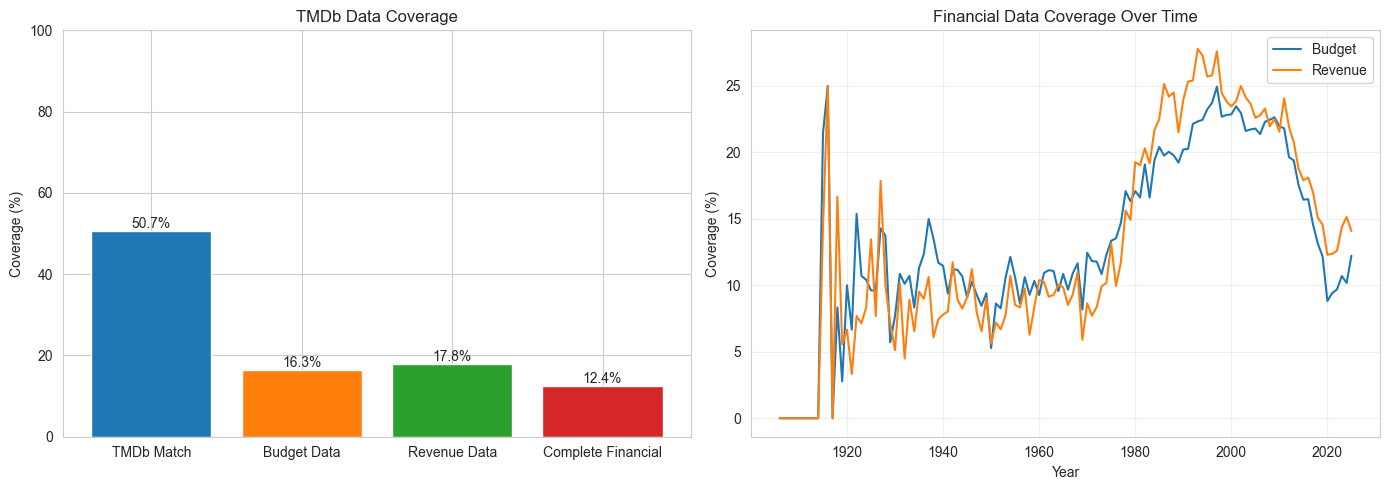

In [9]:
# Visualize data coverage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coverage bar chart
coverage_data = {
    'TMDb Match': with_tmdb/total_movies*100,
    'Budget Data': with_budget/total_movies*100,
    'Revenue Data': with_revenue/total_movies*100,
    'Complete Financial': with_both/total_movies*100
}

ax1 = axes[0]
bars = ax1.bar(coverage_data.keys(), coverage_data.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax1.set_ylabel('Coverage (%)')
ax1.set_title('TMDb Data Coverage')
ax1.set_ylim(0, 100)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom')

# Coverage by year
ax2 = axes[1]
yearly_coverage = df.groupby('startYear').agg({
    'budget': lambda x: (x > 0).sum() / len(x) * 100,
    'revenue': lambda x: (x > 0).sum() / len(x) * 100
})

yearly_coverage.plot(ax=ax2)
ax2.set_xlabel('Year')
ax2.set_ylabel('Coverage (%)')
ax2.set_title('Financial Data Coverage Over Time')
ax2.legend(['Budget', 'Revenue'])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Financial Data Exploration

In [10]:
# Filter for movies with complete financial data
df_financial = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()

print(f"🎬 Movies with complete financial data: {len(df_financial):,}")
print(f"\n💰 Budget Statistics:")
print(f"   Mean: ${df_financial['budget'].mean():,.0f}")
print(f"   Median: ${df_financial['budget'].median():,.0f}")
print(f"   Min: ${df_financial['budget'].min():,.0f}")
print(f"   Max: ${df_financial['budget'].max():,.0f}")

print(f"\n💵 Revenue Statistics:")
print(f"   Mean: ${df_financial['revenue'].mean():,.0f}")
print(f"   Median: ${df_financial['revenue'].median():,.0f}")
print(f"   Min: ${df_financial['revenue'].min():,.0f}")
print(f"   Max: ${df_financial['revenue'].max():,.0f}")

print(f"\n📈 ROI Statistics:")
print(f"   Mean: {df_financial['roi'].mean():.1f}%")
print(f"   Median: {df_financial['roi'].median():.1f}%")

🎬 Movies with complete financial data: 11,558

💰 Budget Statistics:
   Mean: $29,506,852
   Median: $13,000,000
   Min: $1
   Max: $583,900,000

💵 Revenue Statistics:
   Mean: $91,765,576
   Median: $19,489,314
   Min: $1
   Max: $2,923,706,026

📈 ROI Statistics:
   Mean: 49473.4%
   Median: 95.4%


Focusing on 10,747 movies (removed 811 outliers)
Budget range: $0 - $126.1M
Revenue range: $0 - $440.2M


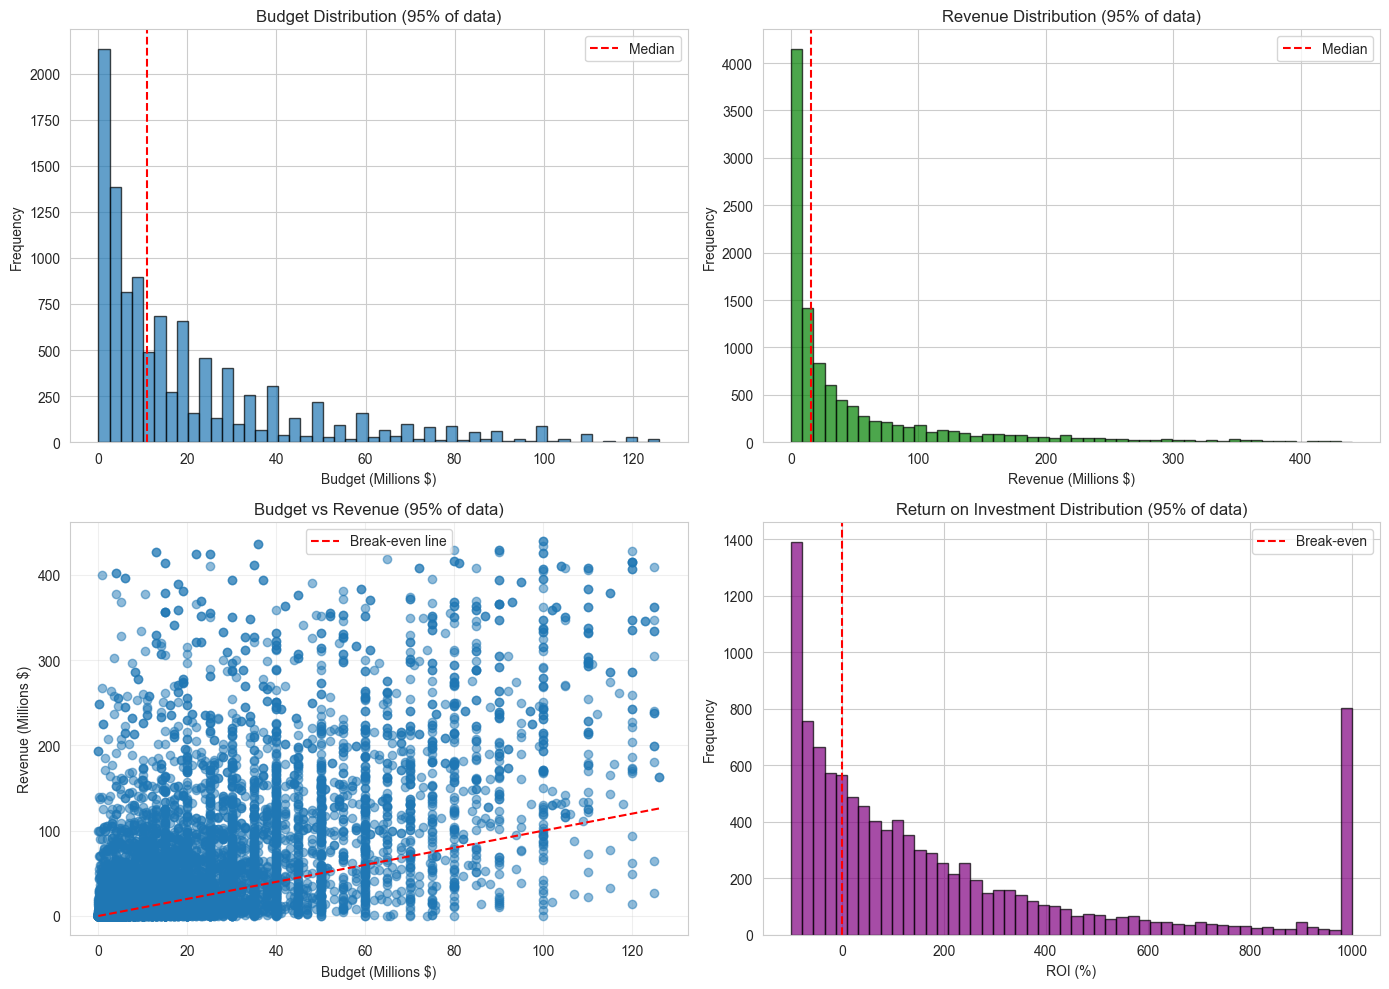

In [11]:
# Calculate percentiles to focus on dense regions
budget_95th = df_financial['budget'].quantile(0.95)
revenue_95th = df_financial['revenue'].quantile(0.95)

# Filter data to focus on main cluster (remove top 5% outliers)
df_main_cluster = df_financial[
    (df_financial['budget'] <= budget_95th) & 
    (df_financial['revenue'] <= revenue_95th)
]

print(f"Focusing on {len(df_main_cluster):,} movies (removed {len(df_financial) - len(df_main_cluster):,} outliers)")
print(f"Budget range: $0 - ${budget_95th/1e6:.1f}M")
print(f"Revenue range: $0 - ${revenue_95th/1e6:.1f}M")

# Visualize budget and revenue distributions (focused view)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Budget distribution (focused)
ax1 = axes[0, 0]
ax1.hist(df_main_cluster['budget'] / 1e6, bins=50, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Budget (Millions $)')
ax1.set_ylabel('Frequency')
ax1.set_title('Budget Distribution (95% of data)')
ax1.axvline(df_main_cluster['budget'].median() / 1e6, color='red', linestyle='--', label='Median')
ax1.legend()

# Revenue distribution (focused)
ax2 = axes[0, 1]
ax2.hist(df_main_cluster['revenue'] / 1e6, bins=50, edgecolor='black', alpha=0.7, color='green')
ax2.set_xlabel('Revenue (Millions $)')
ax2.set_ylabel('Frequency')
ax2.set_title('Revenue Distribution (95% of data)')
ax2.axvline(df_main_cluster['revenue'].median() / 1e6, color='red', linestyle='--', label='Median')
ax2.legend()

# Budget vs Revenue scatter (focused)
ax3 = axes[1, 0]
ax3.scatter(df_main_cluster['budget'] / 1e6, df_main_cluster['revenue'] / 1e6, alpha=0.5)
ax3.plot([0, budget_95th / 1e6], [0, budget_95th / 1e6], 
         'r--', label='Break-even line')
ax3.set_xlabel('Budget (Millions $)')
ax3.set_ylabel('Revenue (Millions $)')
ax3.set_title('Budget vs Revenue (95% of data)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# ROI distribution (focused)
ax4 = axes[1, 1]
# Use main cluster ROI data and clip extreme values
roi_clipped = df_main_cluster['roi'].clip(-100, 1000)
ax4.hist(roi_clipped, bins=50, edgecolor='black', alpha=0.7, color='purple')
ax4.set_xlabel('ROI (%)')
ax4.set_ylabel('Frequency')
ax4.set_title('Return on Investment Distribution (95% of data)')
ax4.axvline(0, color='red', linestyle='--', label='Break-even')
ax4.legend()

plt.tight_layout()
plt.show()

## 6. Relationship Between Financial Data and Ratings

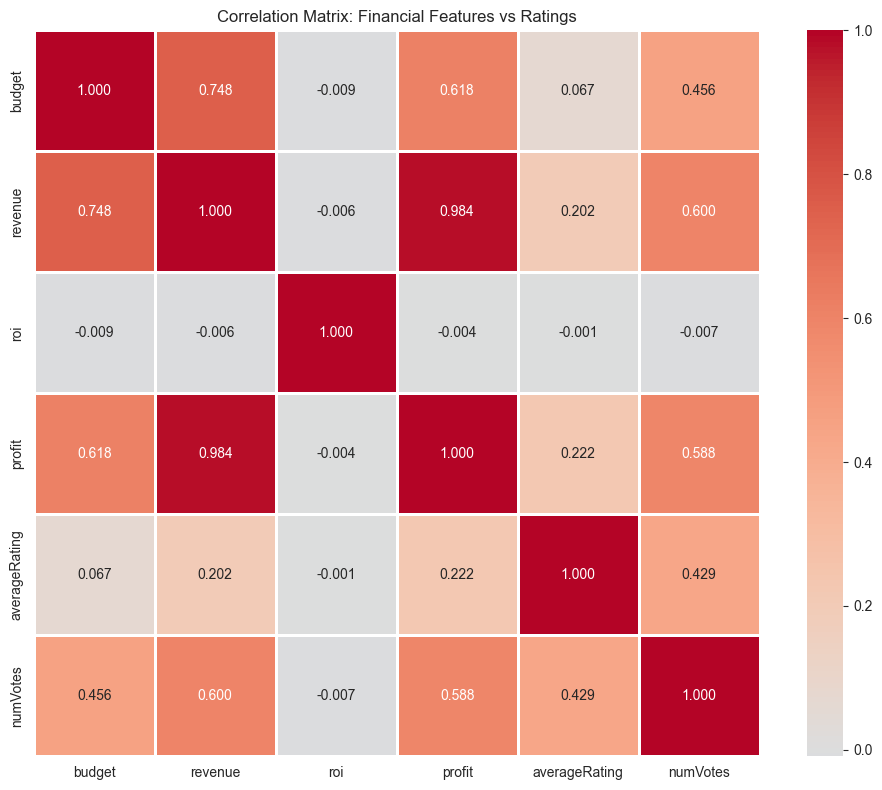

In [12]:
# Correlation analysis
financial_features = ['budget', 'revenue', 'roi', 'profit', 'averageRating', 'numVotes']
correlation_df = df_financial[financial_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_df, annot=True, fmt='.3f', cmap='coolwarm', center=0,
           square=True, linewidths=1)
plt.title('Correlation Matrix: Financial Features vs Ratings')
plt.tight_layout()
plt.show()

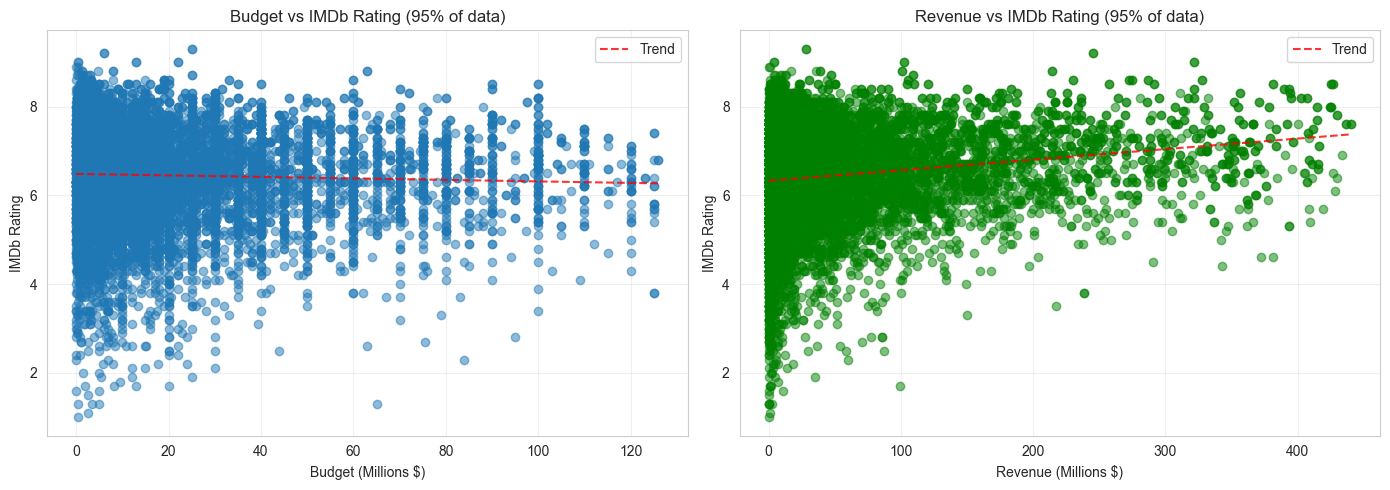

In [13]:
# Budget vs Rating and Revenue vs Rating (focused view)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Budget vs Rating (focused)
ax1 = axes[0]
ax1.scatter(df_main_cluster['budget'] / 1e6, df_main_cluster['averageRating'], alpha=0.5)
ax1.set_xlabel('Budget (Millions $)')
ax1.set_ylabel('IMDb Rating')
ax1.set_title('Budget vs IMDb Rating (95% of data)')
ax1.grid(True, alpha=0.3)

# Add trend line for main cluster
z = np.polyfit(df_main_cluster['budget'], df_main_cluster['averageRating'], 1)
p = np.poly1d(z)
ax1.plot(df_main_cluster['budget'].sort_values() / 1e6, 
        p(df_main_cluster['budget'].sort_values()), "r--", alpha=0.8, label='Trend')
ax1.legend()

# Revenue vs Rating (focused)
ax2 = axes[1]
ax2.scatter(df_main_cluster['revenue'] / 1e6, df_main_cluster['averageRating'], alpha=0.5, color='green')
ax2.set_xlabel('Revenue (Millions $)')
ax2.set_ylabel('IMDb Rating')
ax2.set_title('Revenue vs IMDb Rating (95% of data)')
ax2.grid(True, alpha=0.3)

# Add trend line for main cluster
z = np.polyfit(df_main_cluster['revenue'], df_main_cluster['averageRating'], 1)
p = np.poly1d(z)
ax2.plot(df_main_cluster['revenue'].sort_values() / 1e6, 
        p(df_main_cluster['revenue'].sort_values()), "r--", alpha=0.8, label='Trend')
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Top Movies by Financial Metrics

In [14]:
# Top 10 highest budget movies
print("💰 Top 10 Highest Budget Movies:")
top_budget = df_financial.nlargest(10, 'budget')[['primaryTitle', 'startYear', 'budget', 'revenue', 'averageRating']]
top_budget['budget'] = top_budget['budget'].apply(lambda x: f"${x/1e6:.1f}M")
top_budget['revenue'] = top_budget['revenue'].apply(lambda x: f"${x/1e6:.1f}M")
display(top_budget)

💰 Top 10 Highest Budget Movies:


,primaryTitle,startYear,budget,revenue,averageRating
47670,Jurassic World: Dominion,2022.0,$583.9M,$1004.0M,5.6
327,Star Wars: Episode IX - The Rise of Skywalker,2019.0,$416.0M,$1074.1M,6.4
46939,Star Wars: Episode IX - The Rise of Skywalker,2019.0,$416.0M,$1074.1M,6.4
48201,Mission: Impossible - The Final Reckoning,2025.0,$400.0M,$598.1M,7.2
273,Pirates of the Caribbean: On Stranger Tides,2011.0,$379.0M,$1046.7M,6.6
46885,Pirates of the Caribbean: On Stranger Tides,2011.0,$379.0M,$1046.7M,6.6
86,Avengers: Age of Ultron,2015.0,$365.0M,$1405.4M,7.3
46698,Avengers: Age of Ultron,2015.0,$365.0M,$1405.4M,7.3
34,Avengers: Endgame,2019.0,$356.0M,$2799.4M,8.4
46646,Avengers: Endgame,2019.0,$356.0M,$2799.4M,8.4


In [15]:
# Top 10 highest revenue movies
print("💵 Top 10 Highest Revenue Movies:")
top_revenue = df_financial.nlargest(10, 'revenue')[['primaryTitle', 'startYear', 'budget', 'revenue', 'averageRating']]
top_revenue['budget'] = top_revenue['budget'].apply(lambda x: f"${x/1e6:.1f}M")
top_revenue['revenue'] = top_revenue['revenue'].apply(lambda x: f"${x/1e6:.1f}M")
display(top_revenue)

💵 Top 10 Highest Revenue Movies:


,primaryTitle,startYear,budget,revenue,averageRating
31,Avatar,2009.0,$237.0M,$2923.7M,7.9
46643,Avatar,2009.0,$237.0M,$2923.7M,7.9
34,Avengers: Endgame,2019.0,$356.0M,$2799.4M,8.4
46646,Avengers: Endgame,2019.0,$356.0M,$2799.4M,8.4
308,Avatar: The Way of Water,2022.0,$350.0M,$2330.2M,7.5
46920,Avatar: The Way of Water,2022.0,$350.0M,$2330.2M,7.5
35,Titanic,1997.0,$200.0M,$2264.2M,7.9
46647,Titanic,1997.0,$200.0M,$2264.2M,7.9
88755,How Could I Live Without You?,2024.0,$70.0M,$2200.0M,6.9
55099,Ne Zha 2,2025.0,$80.0M,$2150.0M,8.0


In [16]:
# Top 10 highest ROI movies
print("📈 Top 10 Highest ROI Movies:")
top_roi = df_financial.nlargest(10, 'roi')[['primaryTitle', 'startYear', 'budget', 'revenue', 'roi', 'averageRating']]
top_roi['budget'] = top_roi['budget'].apply(lambda x: f"${x/1e6:.1f}M")
top_roi['revenue'] = top_roi['revenue'].apply(lambda x: f"${x/1e6:.1f}M")
top_roi['roi'] = top_roi['roi'].apply(lambda x: f"{x:.0f}%")
display(top_roi)

📈 Top 10 Highest ROI Movies:


,primaryTitle,startYear,budget,revenue,roi,averageRating
91730,Oy Vey! My Son Is Gay!!,2009.0,$0.0M,$6.0M,300000250%,5.2
56368,The Beatles: Eight Days a Week - The Touring Y...,2016.0,$0.0M,$12.3M,245675900%,7.8
89181,"Dad, I'm Sorry",2021.0,$0.0M,$17.1M,13383095%,6.6
57405,The Notorious Bettie Page,2005.0,$0.0M,$1.4M,1567431%,6.5
60483,Scrapper,2023.0,$0.0M,$1.2M,1469523%,6.9
898,Paranormal Activity,2007.0,$0.0M,$193.4M,1288939%,6.3
47510,Paranormal Activity,2007.0,$0.0M,$193.4M,1288939%,6.3
61715,Tarnation,2003.0,$0.0M,$1.2M,532934%,7.1
735,The Blair Witch Project,1999.0,$0.1M,$248.6M,414298%,6.5
47347,The Blair Witch Project,1999.0,$0.1M,$248.6M,414298%,6.5


## 8. Next Steps

Now that you have financial data integrated, you can:

1. **Feature Engineering**: Create new features from financial data
   - Budget categories (low/medium/high)
   - Log-transformed financial values
   - Budget-to-rating ratios

2. **Enhanced Modeling**: Build models that predict ratings using financial data
   - Does higher budget lead to higher ratings?
   - Do certain production companies correlate with better ratings?
   
3. **Multi-target Prediction**: Predict both ratings AND revenue
   - Build models to predict box office success
   - Understand what makes movies commercially successful

4. **Production Analysis**: Analyze production countries and companies
   - Which countries produce highest-rated movies?
   - Which production companies are most successful?

In [17]:
# Save the financial subset for modeling
output_file = '../data/processed/movies_with_financial_data.parquet'
df_financial.to_parquet(output_file, index=False)
print(f"💾 Saved {len(df_financial):,} movies with complete financial data to:")
print(f"   {output_file}")

💾 Saved 11,558 movies with complete financial data to:
   ../data/processed/movies_with_financial_data.parquet
